### 06 Align plaques TIFF image to Xenium coordinates -- copy with my codes

This notebook aligns `morphology.ome.tiff` to the Xenium spatial coordinates in `05_scvi.h5ad`, writes QC overlays, optionally applies manual landmark correction, segments plaque-like signal, and assigns each cell to its nearest plaque.

Run the cells from top to bottom. After the first run, inspect `qc_initial_morphology_xenium_overlay.png`, `qc_final_morphology_xenium_overlay.png`, and `qc_plaque_segmentation.png` in the working directory. If the overlay needs correction, fill the generated `manual_landmarks.csv` and rerun the landmark/alignment cells.

In [1]:
from importlib.machinery import SourceFileLoader
import json
import os
import sys
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Any
import tifffile as tf # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np
import pandas as pd # type: ignore
import scanpy as sc # type: ignore
from scipy.spatial import cKDTree # type: ignore
from skimage.filters import gaussian, threshold_otsu # type: ignore
from skimage.measure import label, regionprops_table # type: ignore
from skimage.morphology import (
    binary_closing,
    binary_opening,
    disk,
    remove_small_holes,
    remove_small_objects,
) # type: ignore
from skimage.transform import AffineTransform, estimate_transform # type: ignore
import importlib.util
import sys
from pathlib import Path

module_path = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py")
sys.modules.pop("plaques_alignment", None)

spec = importlib.util.spec_from_file_location("plaques_alignment", module_path)
plaques_alignment = importlib.util.module_from_spec(spec)
sys.modules["plaques_alignment"] = plaques_alignment
spec.loader.exec_module(plaques_alignment)

print("Loaded:", plaques_alignment)

Loaded: <module 'plaques_alignment' from '/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex/06_plaques_alignment.py'>


### Catch the best z plane

In [2]:
WORKING_DIRECTORY = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment")
MORPHOLOGY_PATH = Path('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif').expanduser()

z_dir = WORKING_DIRECTORY / "morphology_z_plane_checks"
z_dir.mkdir(parents=True, exist_ok=True)

def robust_rescale(img, lower=1, upper=99.8):
    img = img.astype(float, copy=False)
    lo, hi = np.nanpercentile(img, [lower, upper])

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(img, dtype=float)

    return np.clip((img - lo) / (hi - lo), 0, 1)


z_dir = WORKING_DIRECTORY / "morphology_z_plane_checks"
z_dir.mkdir(parents=True, exist_ok=True)

with tf.TiffFile(MORPHOLOGY_PATH) as tiff:
    series = tiff.series[0]
    levels = getattr(series, "levels", None) or [series]
    level = levels[min(2, len(levels) - 1)]
    arr = level.asarray()

print(arr.shape)

for z in range(arr.shape[0]):
    img = arr[z, :, :]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(robust_rescale(img), cmap="gray", origin="upper")
    ax.set_title(f"Z plane {z}")
    ax.axis("off")

    out = z_dir / f"z_plane_{z:02d}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)

    print(out)

(13, 7681, 9968)
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_00.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_01.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/morphology_z_plane_checks/z_plane_02.png
/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAE

### Inputs

In [3]:
WORKING_DIRECTORY = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment")
INPUT_DIR = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI")
MORPHOLOGY_PATH = Path('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif').expanduser()

H5AD_PATH = INPUT_DIR / "05_scvi.h5ad"
ALIGNED_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_morphology_alignment.h5ad"
PLAQUE_H5AD_PATH = WORKING_DIRECTORY / "05_scvi_with_plaque_distances.h5ad"
LANDMARK_TEMPLATE_PATH = WORKING_DIRECTORY / "manual_landmarks_template.csv"
LANDMARK_PATH = WORKING_DIRECTORY / "manual_landmarks.csv"

WORKING_DIRECTORY.mkdir(parents=True, exist_ok=True)
os.chdir(WORKING_DIRECTORY)

print(f"Working directory: {Path.cwd()}")
print(f"Input h5ad: {H5AD_PATH}")
print(f"Morphology image: {MORPHOLOGY_PATH}")

assert H5AD_PATH.exists(), f"Missing h5ad: {H5AD_PATH}"
assert MORPHOLOGY_PATH.exists(), f"Missing morphology image: {MORPHOLOGY_PATH}"

Working directory: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment
Input h5ad: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/04_SCVI/05_scvi.h5ad
Morphology image: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif


In [4]:

COORDINATE_UNITS = "micron"

DISPLAY_LEVEL = 2
PLAQUE_CHANNEL_INDEX = None
RUN_PLAQUE_SEGMENTATION = True

PLAQUE_SMOOTH_SIGMA = 1.0
PLAQUE_THRESHOLD_MULTIPLIER = 1.0
MIN_PLAQUE_AREA_UM2 = 25.0
MAX_HOLE_AREA_UM2 = 25.0
PLAQUE_OPENING_RADIUS_PX = 1
PLAQUE_CLOSING_RADIUS_PX = 2

PLAQUE_NEIGHBOR_RADIUS = 50

LANDMARK_TRANSFORM_TYPE = "similarity"

In [5]:
module_globals = [
    "WORKING_DIRECTORY",
    "MORPHOLOGY_PATH",
    "H5AD_PATH",
    "ALIGNED_H5AD_PATH",
    "PLAQUE_H5AD_PATH",
    "LANDMARK_TEMPLATE_PATH",
    "LANDMARK_PATH",
    "COORDINATE_UNITS",
    "LANDMARK_TRANSFORM_TYPE",
    "MIN_PLAQUE_AREA_UM2",
    "MAX_HOLE_AREA_UM2",
    "PLAQUE_SMOOTH_SIGMA",
    "PLAQUE_THRESHOLD_MULTIPLIER",
    "PLAQUE_OPENING_RADIUS_PX",
    "PLAQUE_CLOSING_RADIUS_PX",
    "PLAQUE_NEIGHBOR_RADIUS",
]

for name in module_globals:
    if name in globals():
        setattr(plaques_alignment, name, globals()[name])
    else:
        print(f"Missing in notebook: {name}")

### Load xenium objects and coordinates

In [6]:
adata = sc.read_h5ad(H5AD_PATH)
xenium_xy, coordinate_source = plaques_alignment.get_xenium_coordinates(adata)
adata.obsm["xenium_xy"] = xenium_xy[["x", "y"]].to_numpy(float)

print(adata)
print(f"Coordinate source: {coordinate_source}")
print(
    "Coordinate ranges: "
    f"x={xenium_xy['x'].min():.2f}..{xenium_xy['x'].max():.2f}, "
    f"y={xenium_xy['y'].min():.2f}..{xenium_xy['y'].max():.2f}"
)
print("obsm keys:", list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 158112 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5', 'Topic 6', 'Topic 7', 'Topic 8', 'Topic 9', 'Topic 10', 'Topic 11', 'Topic 12', 'Topic 13', 'Topic 14', 'Topic 15', 'topic', 'batch', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bad_tissue_filtering', 'batch_colors', 'filtering_downsize', 'filtering_image_padding', 'initial_neighborhood_parameters', 'leiden', 'leiden_colors', 'scvi', 'scvi_inp

### Read the best single z level (z_plane_03)

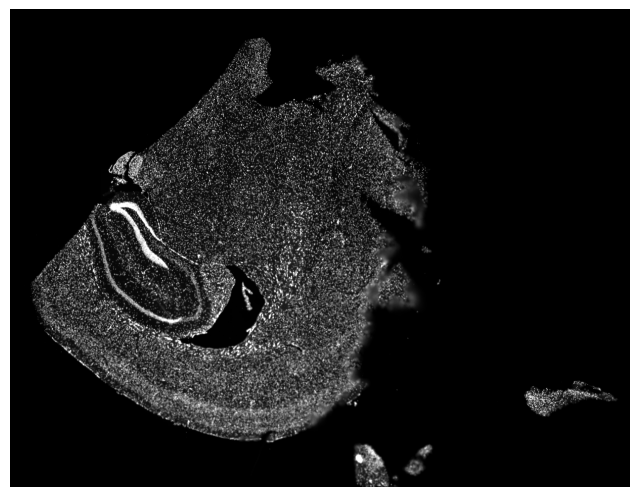

In [7]:
BEST_Z = 3  # change to your best z plane
DISPLAY_LEVEL = 2

def read_ome_level_single_z(path, level_index=2, z_index=0):
    with tf.TiffFile(path) as tif:
        series = tif.series[0]
        levels = getattr(series, "levels", None) or [series]
        level = levels[min(level_index, len(levels) - 1)]

        arr = np.asarray(level.asarray())
        axes = level.axes.upper()

    if axes == "ZYX":
        img = arr[z_index, :, :]
    elif "Z" in axes and "Y" in axes and "X" in axes:
        z_axis = axes.index("Z")
        arr_z = np.take(arr, z_index, axis=z_axis)

        axes_no_z = axes.replace("Z", "")
        y_axis = axes_no_z.index("Y")
        x_axis = axes_no_z.index("X")

        img = np.moveaxis(arr_z, [y_axis, x_axis], [0, 1])
    else:
        img = np.squeeze(arr)

    img = np.squeeze(img)

    if img.ndim != 2:
        raise ValueError(f"Expected 2D image after selecting Z={z_index}, got {img.shape}")

    return img

display_img = read_ome_level_single_z(
    MORPHOLOGY_PATH,
    level_index=DISPLAY_LEVEL,
    z_index=BEST_Z,
)

plt.figure(figsize=(8, 8))
plt.imshow(robust_rescale(display_img), cmap="gray", origin="upper")
plt.axis("off")
plt.show()

### Load the APPS/PS1 infected and APPS/PS1 mock separately

In [9]:
def get_xy_from_adata(adata_obj):
    if {"x_centroid", "y_centroid"}.issubset(adata_obj.obs.columns):
        xy = adata_obj.obs[["x_centroid", "y_centroid"]].astype(float).copy()
        xy.columns = ["x", "y"]
        return xy

    if "X_spatial" in adata_obj.obsm:
        xy = pd.DataFrame(
            adata_obj.obsm["X_spatial"][:, :2],
            index=adata_obj.obs_names,
            columns=["x", "y"],
        )
        return xy

    raise KeyError("Could not find x_centroid/y_centroid or X_spatial.")

In [10]:
def overlay_one_sample(
    adata_obj,
    sample_name,
    morphology_path,
    output_name,
    z_index=BEST_Z,
    display_level=DISPLAY_LEVEL,
):
    sample_dir = WORKING_DIRECTORY / f"{sample_name}_morphology_alignment"
    sample_dir.mkdir(parents=True, exist_ok=True)

    ome_meta = plaques_alignment.inspect_ome_tiff(morphology_path)

    display_img = read_ome_level_single_z(
        morphology_path,
        level_index=display_level,
        z_index=z_index,
    )

    display_image_info = {
        "height_px": display_img.shape[0],
        "width_px": display_img.shape[1],
    }

    xenium_xy = get_xy_from_adata(adata_obj)

    native_transform = plaques_alignment.make_native_image_to_xenium_transform(
        COORDINATE_UNITS,
        float(ome_meta["physical_size_x"]),
        float(ome_meta["physical_size_y"]),
    )

    initial_cell_fullres_px = native_transform.inverse(
        xenium_xy[["x", "y"]].to_numpy(float)
    )

    adata_obj.obsm["morphology_fullres_px_initial"] = initial_cell_fullres_px

    initial_cell_level_px = plaques_alignment.fullres_to_level_points(
        initial_cell_fullres_px,
        tuple(ome_meta["fullres_shape_yx"]),
        (display_image_info["height_px"], display_image_info["width_px"]),
    )

    plaques_alignment.plot_morphology_overlay(
        display_img,
        initial_cell_level_px,
        f"{sample_name} initial metadata-based Xenium cell overlay",
        sample_dir / output_name,
    )

    print(f"Saved: {sample_dir / output_name}")
    return adata_obj

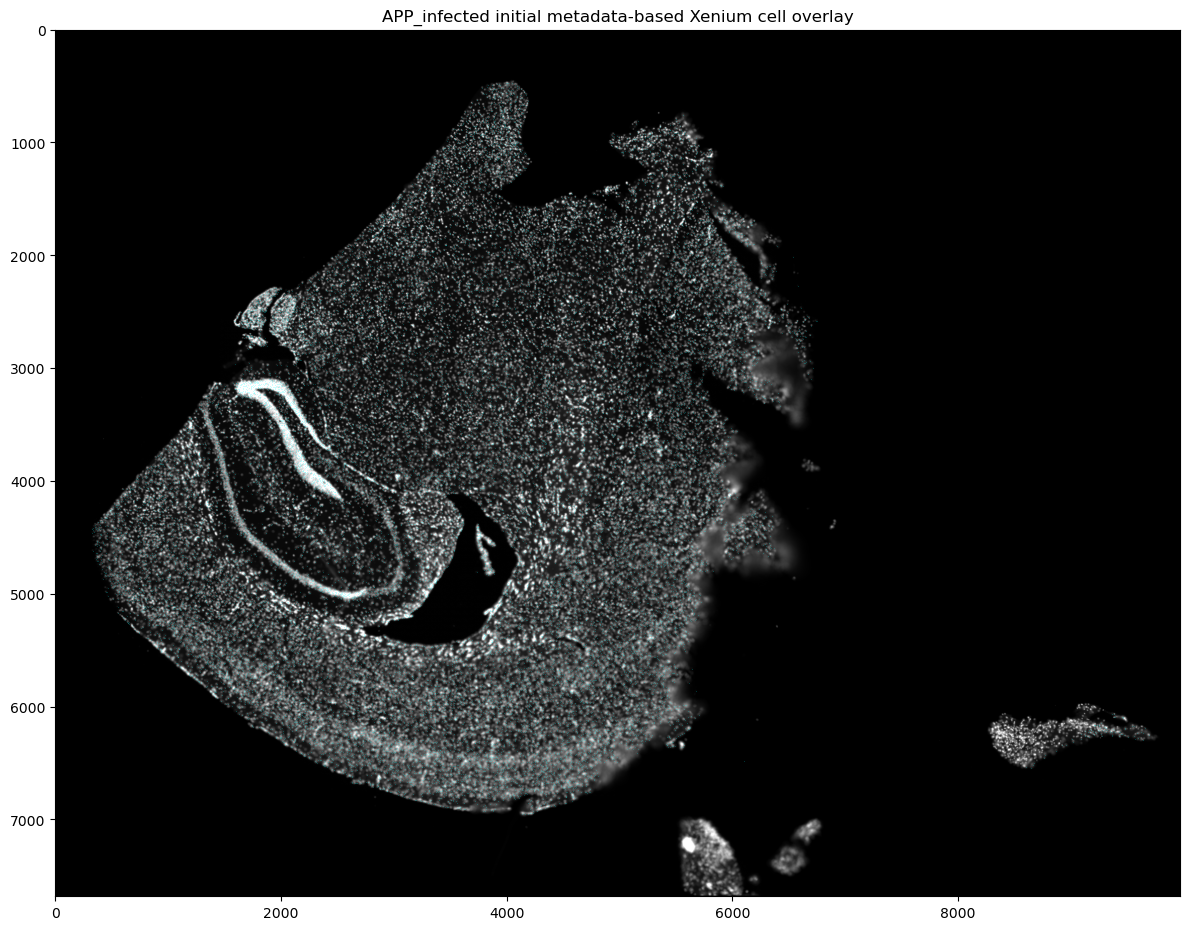

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_infected_morphology_alignment/qc_initial_APP_infected_overlay.png
Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_infected_morphology_alignment/qc_initial_APP_infected_overlay.png


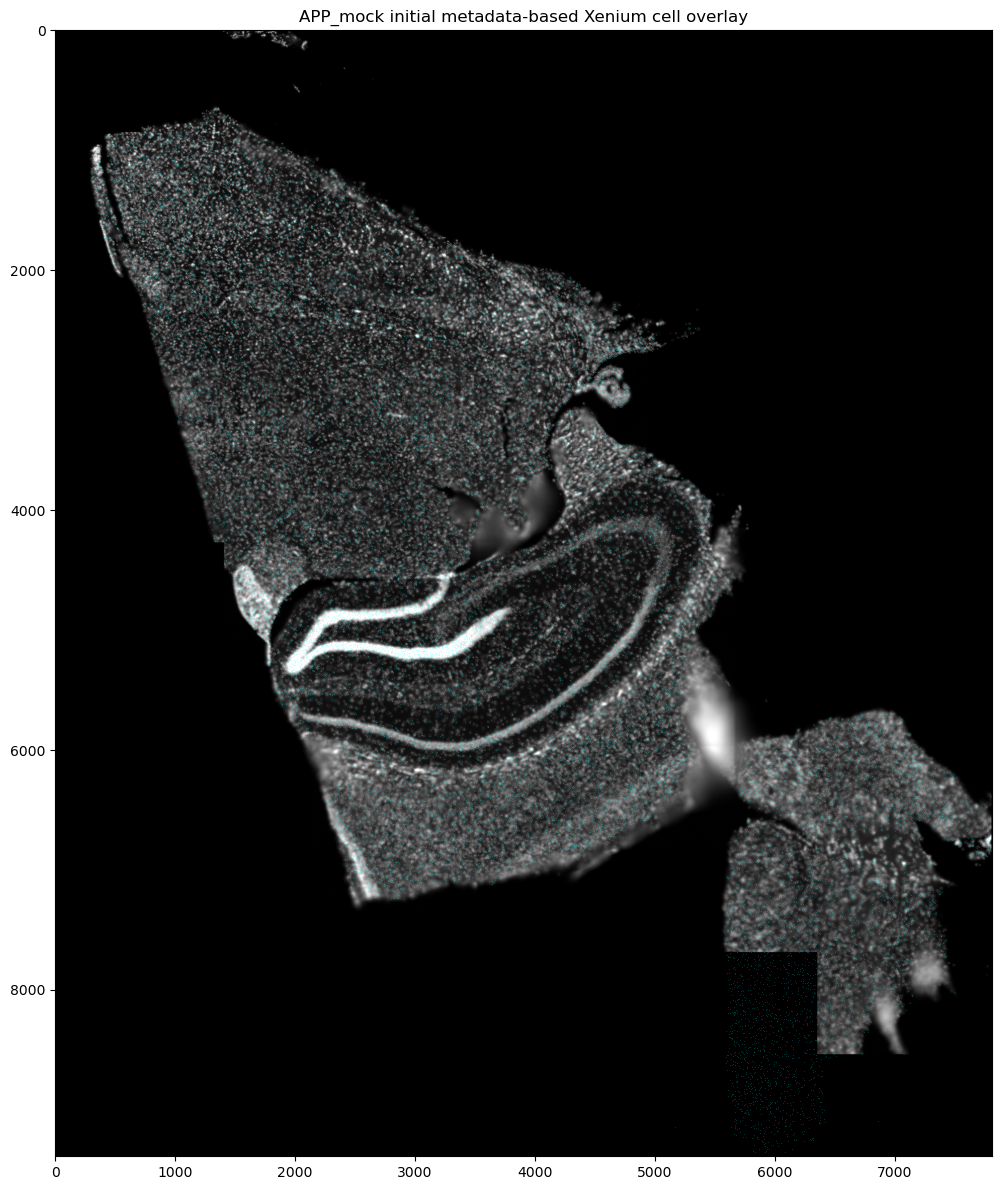

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_mock_morphology_alignment/qc_initial_APP_mock_overlay.png
Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_mock_morphology_alignment/qc_initial_APP_mock_overlay.png


In [11]:
APP_INF_MORPHOLOGY = Path(
    "/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif"
)

APP_MOCK_MORPHOLOGY = Path(
    "/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_mock_437f2__20240627__192344/morphology.ome.tif"
)

adata_inf = adata[adata.obs["batch"].astype(str) == "AD_inf"].copy()
adata_mock = adata[adata.obs["batch"].astype(str) == "AD_mock"].copy()

adata_inf = overlay_one_sample(
    adata_inf,
    sample_name="APP_infected",
    morphology_path=APP_INF_MORPHOLOGY,
    output_name="qc_initial_APP_infected_overlay.png",
)

adata_mock = overlay_one_sample(
    adata_mock,
    sample_name="APP_mock",
    morphology_path=APP_MOCK_MORPHOLOGY,
    output_name="qc_initial_APP_mock_overlay.png",
)

In [16]:
def overlay_and_save_one_sample(
    adata_obj,
    sample_name,
    morphology_path,
    z_index=BEST_Z,
    display_level=DISPLAY_LEVEL,
):
    sample_dir = WORKING_DIRECTORY / f"{sample_name}_morphology_alignment"
    sample_dir.mkdir(parents=True, exist_ok=True)

    ome_meta = plaques_alignment.inspect_ome_tiff(morphology_path)

    display_img = read_ome_level_single_z(
        morphology_path,
        level_index=display_level,
        z_index=z_index,
    )

    display_image_info = {
        "height_px": display_img.shape[0],
        "width_px": display_img.shape[1],
    }

    xenium_xy = get_xy_from_adata(adata_obj)

    native_transform = plaques_alignment.make_native_image_to_xenium_transform(
        COORDINATE_UNITS,
        float(ome_meta["physical_size_x"]),
        float(ome_meta["physical_size_y"]),
    )

    cell_fullres_px = native_transform.inverse(
        xenium_xy[["x", "y"]].to_numpy(float)
    )

    cell_level_px = plaques_alignment.fullres_to_level_points(
        cell_fullres_px,
        tuple(ome_meta["fullres_shape_yx"]),
        (display_image_info["height_px"], display_image_info["width_px"]),
    )

    adata_obj = adata_obj.copy()
    adata_obj.obsm["morphology_fullres_px"] = cell_fullres_px
    adata_obj.obsm["morphology_display_level_px"] = cell_level_px

    adata_obj.uns["morphology_alignment"] = {
        "sample_name": sample_name,
        "morphology_path": str(morphology_path),
        "z_index": int(z_index),
        "display_level": int(display_level),
        "coordinate_units": COORDINATE_UNITS,
        "physical_size_x": float(ome_meta["physical_size_x"]),
        "physical_size_y": float(ome_meta["physical_size_y"]),
        "fullres_shape_yx": list(map(int, ome_meta["fullres_shape_yx"])),
        "image_to_xenium_matrix": native_transform.params,
        "xenium_to_image_matrix": np.linalg.inv(native_transform.params),
    }

    image_path = sample_dir / f"{sample_name}_morphology_alignment_overlay.png"
    h5ad_path = sample_dir / f"{sample_name}_with_morphology_alignment.h5ad"

    plaques_alignment.plot_morphology_overlay(
        display_img,
        cell_level_px,
        f"{sample_name} morphology alignment",
        image_path,
    )

    adata_obj.write_h5ad(h5ad_path)

    print(f"Saved image: {image_path}")
    print(f"Saved h5ad:  {h5ad_path}")

    return adata_obj

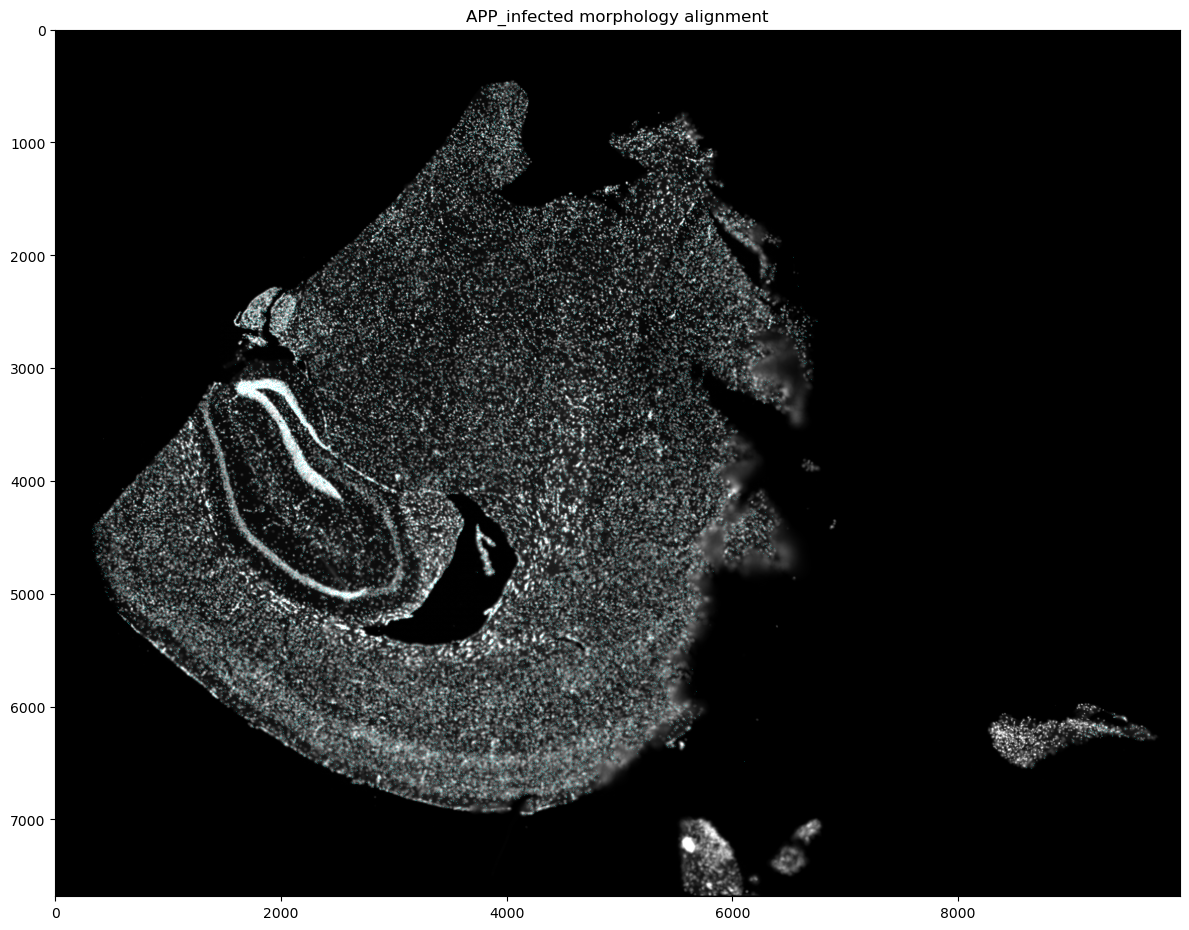

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_infected_morphology_alignment/APP_infected_morphology_alignment_overlay.png
Saved image: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_infected_morphology_alignment/APP_infected_morphology_alignment_overlay.png
Saved h5ad:  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_infected_morphology_alignment/APP_infected_with_morphology_alignment.h5ad


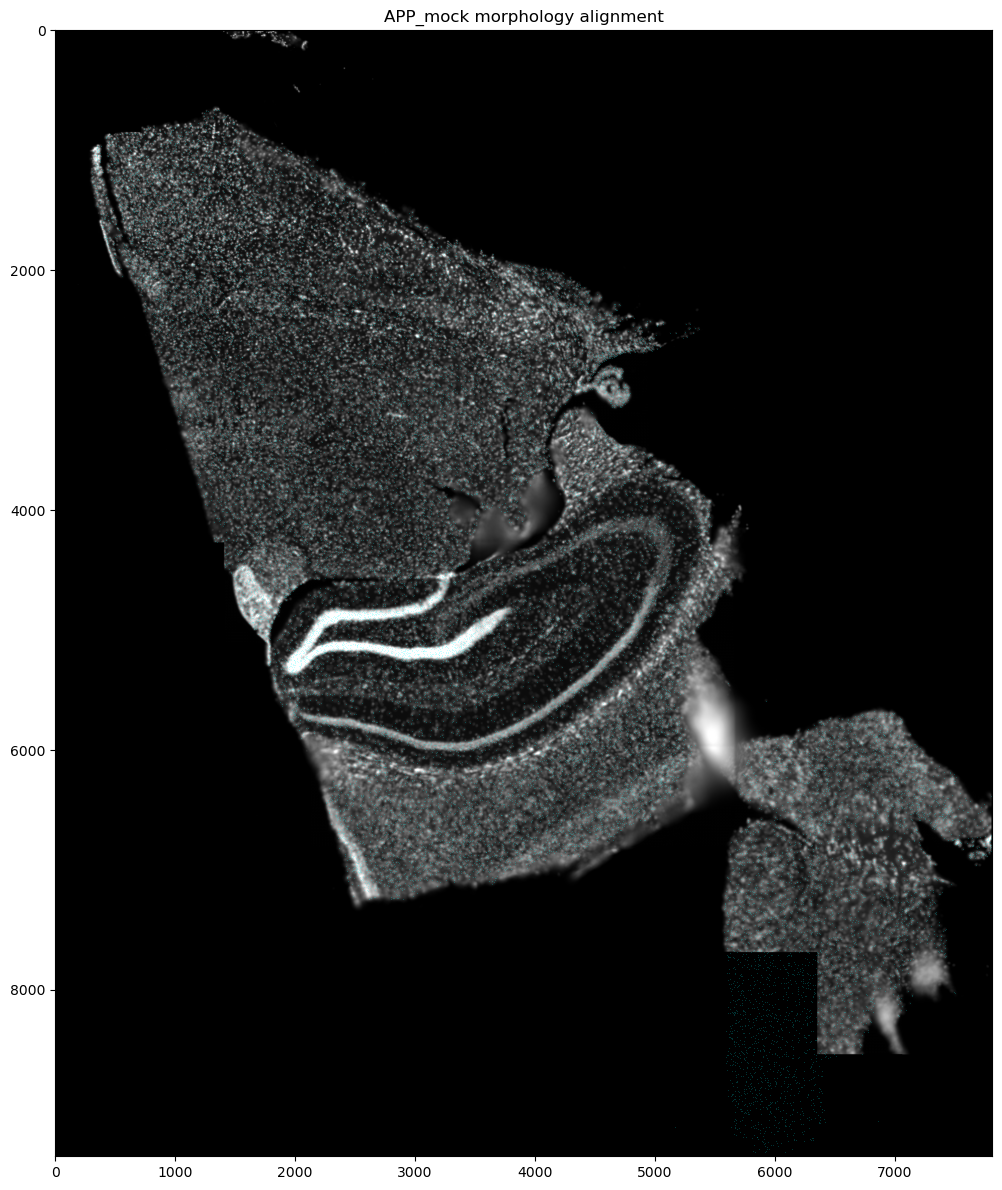

Saved: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_mock_morphology_alignment/APP_mock_morphology_alignment_overlay.png
Saved image: /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_mock_morphology_alignment/APP_mock_morphology_alignment_overlay.png
Saved h5ad:  /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/06_plaques_image_alignment/APP_mock_morphology_alignment/APP_mock_with_morphology_alignment.h5ad


In [17]:
adata_inf_aligned = overlay_and_save_one_sample(
    adata_inf,
    sample_name="APP_infected",
    morphology_path=APP_INF_MORPHOLOGY,
)

adata_mock_aligned = overlay_and_save_one_sample(
    adata_mock,
    sample_name="APP_mock",
    morphology_path=APP_MOCK_MORPHOLOGY,
)